# EDA CNPJ Estabelecimentos

## Setup

In [1]:
import os
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UserWarning, module="pyspark")

current_path = os.getcwd()
project_root = Path(current_path).parent.parent
os.chdir(project_root)
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64"

## Read and first check

In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
import glob



spark = SparkSession.builder \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "8g") \
    .getOrCreate()

files = glob.glob("data/raw/cnpj/*.parquet")
                    
cnpj_df = (
    spark.read
    .option("mergeSchema", "true")
    .parquet(*glob.glob(os.path.abspath("data/raw/cnpj/*2022*.parquet")))
)
n_reg = cnpj_df.count()
print(f"CNPJ rows: {n_reg:,d}")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/30 16:05:12 WARN Utils: Your hostname, lucas-vital-Q570M-D3H, resolves to a loopback address: 127.0.1.1; using 192.168.100.25 instead (on interface wlp8s0)
26/08/30 16:05:12 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/30 16:05:13 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


CNPJ rows: 480,847,120


In [3]:
cnpj_df.show(5)

26/08/30 16:05:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+---------------+--------------+-----------+----------+-------+---------------------------+-----------------+------------------+-----------------------+-------------------------+--------------------+-------+---------------------+---------------------+----------------------+--------+------------+---------------+---------------+------------------+------+-----------+-------------+--------+-----+----------+-----+----------+-------+----+--------------------+-----------------+----------------+----------------------+
|data_referencia|          cnpj|cnpj_basico|cnpj_ordem|cnpj_dv|identificador_matriz_filial|    nome_fantasia|situacao_cadastral|data_situacao_cadastral|motivo_situacao_cadastral|nome_cidade_exterior|id_pais|data_inicio_atividade|cnae_fiscal_principal|cnae_fiscal_secundaria|sigla_uf|id_municipio|id_municipio_rf|tipo_logradouro|        logradouro|numero|complemento|       bairro|     cep|ddd_1|telefone_1|ddd_2|telefone_2|ddd_fax| fax|               email|situacao_especial|data_modi

In [4]:
cnpj_df.printSchema()

root
 |-- data_referencia: date (nullable = true)
 |-- cnpj: string (nullable = true)
 |-- cnpj_basico: string (nullable = true)
 |-- cnpj_ordem: string (nullable = true)
 |-- cnpj_dv: string (nullable = true)
 |-- identificador_matriz_filial: string (nullable = true)
 |-- nome_fantasia: string (nullable = true)
 |-- situacao_cadastral: string (nullable = true)
 |-- data_situacao_cadastral: date (nullable = true)
 |-- motivo_situacao_cadastral: string (nullable = true)
 |-- nome_cidade_exterior: string (nullable = true)
 |-- id_pais: string (nullable = true)
 |-- data_inicio_atividade: date (nullable = true)
 |-- cnae_fiscal_principal: string (nullable = true)
 |-- cnae_fiscal_secundaria: string (nullable = true)
 |-- sigla_uf: string (nullable = true)
 |-- id_municipio: string (nullable = true)
 |-- id_municipio_rf: string (nullable = true)
 |-- tipo_logradouro: string (nullable = true)
 |-- logradouro: string (nullable = true)
 |-- numero: string (nullable = true)
 |-- complemento: s

## analyse missingness

In [5]:
from pyspark.sql import functions as F

total_rows = cnpj_df.count()

fulfillment_exprs = [
    F.struct(
        F.lit(c).alias("column"),
        (F.count(F.col(c)) / F.lit(total_rows) * 100).alias("fulfillment_pct")
    )
    for c in cnpj_df.columns
]

result = cnpj_df.select(F.array(*fulfillment_exprs).alias("stats")) \
    .selectExpr("explode(stats) as stats") \
    .select("stats.column", "stats.fulfillment_pct")

result.orderBy(F.col("fulfillment_pct").desc()).show(cnpj_df.columns.__len__(), truncate=False)

+---------------------------+---------------------+
|column                     |fulfillment_pct      |
+---------------------------+---------------------+
|data_referencia            |100.0                |
|cnpj                       |100.0                |
|cnpj_basico                |100.0                |
|cnpj_ordem                 |100.0                |
|cnpj_dv                    |100.0                |
|identificador_matriz_filial|100.0                |
|situacao_cadastral         |100.0                |
|motivo_situacao_cadastral  |100.0                |
|cnae_fiscal_principal      |100.0                |
|sigla_uf                   |100.0                |
|id_municipio_rf            |100.0                |
|numero                     |100.0                |
|data_inicio_atividade      |99.99999979203369    |
|logradouro                 |99.99622395575541    |
|data_situacao_cadastral    |99.71644501063041    |
|cep                        |99.71062403368455    |
|id_municipi

## Distribuição por estado

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/08/30 16:09:29 ERROR Executor: Exception in task 136.0 in stage 14.0 (TID 1717)
org.apache.spark.SparkException: [FAILED_READ_FILE.NO_HINT] Encountered error while reading file file:///home/lucas-vital/projects/brazilian_address_linkage/data/raw/cnpj/extracted_data_cnpj_estabelecimentos_2022_10.parquet/part-00043-6854335b-fce6-4960-a580-f6459e50ccd7-c000.snappy.parquet.  SQLSTATE: KD001
	at org.apache.spark.sql.errors.QueryExecutionErrors$.cannotReadFilesError(QueryExecutionErrors.scala:940)
	at org.apache.spark.sql.execution.datasources.v2.FileDataSourceV2$.attachFilePath(FileDataSourceV2.scala:142)
	at org.apache.spark.sql.execution.datasources.FileScanRDD$$anon$1.hasNext

<Axes: title={'center': 'CNPJ count per UF'}, ylabel='sigla_uf'>

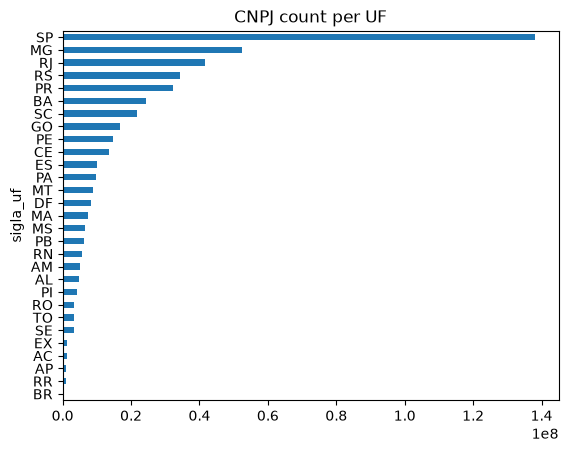

In [7]:
count_per_uf_df = cnpj_df.groupBy("sigla_uf").count().toPandas().sort_values("count", ascending=True)
count_per_uf_df.plot.barh(x="sigla_uf", y="count", legend=False, title="CNPJ count per UF")

In [8]:
count_per_uf_df

,sigla_uf,count
28,BR,9
5,RR,934696
27,AP,1112401
24,AC,1157407
4,EX,1391739
18,SE,3221500
7,TO,3246688
1,RO,3431263
2,PI,4269913
14,AL,4658048


## Distribuição situação cadastral

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


<Axes: title={'center': 'CNPJ count per situacao_cadastral'}, ylabel='situacao_cadastral'>

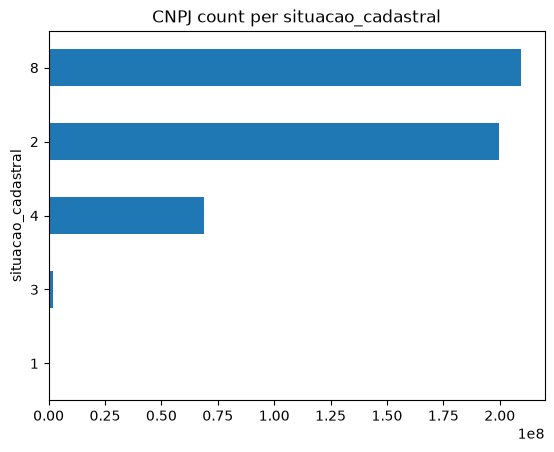

In [9]:
sit_cadastral_count_df = cnpj_df.groupBy("situacao_cadastral").count().toPandas().sort_values("count", ascending=True)
sit_cadastral_count_df.plot.barh(x="situacao_cadastral", y="count", legend=False, title="CNPJ count per situacao_cadastral")

### Por Estado

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


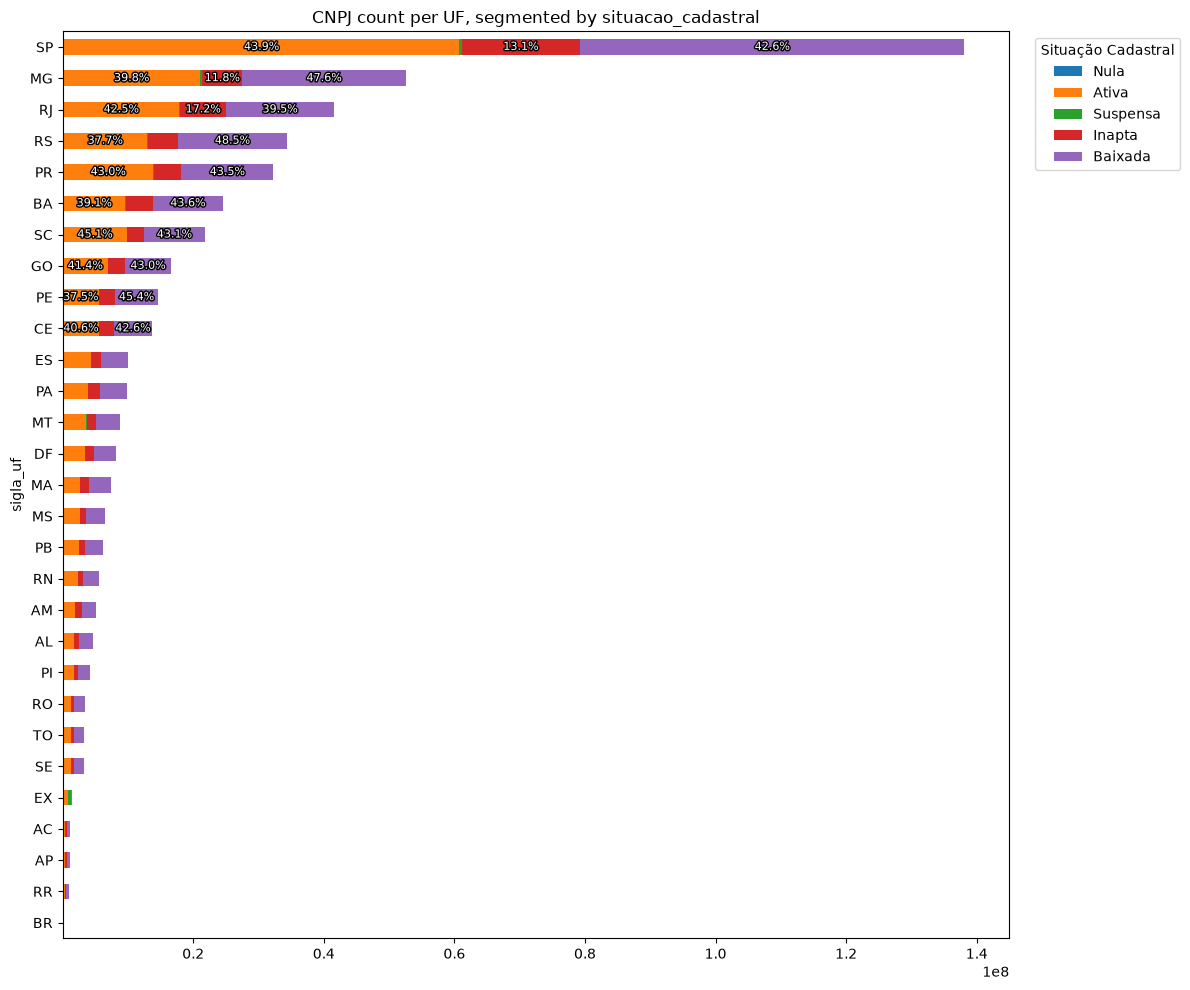

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe

situacao_cadastral_dict = {
    "1": "Nula",
    "2": "Ativa",
    "3": "Suspensa",
    "4": "Inapta",
    "8": "Baixada",
}

count_per_uf_df = (
    cnpj_df.groupBy("sigla_uf", "situacao_cadastral")
    .count()
    .toPandas()
    .pivot(index="sigla_uf", columns="situacao_cadastral", values="count")
    .fillna(0)
)

count_per_uf_df = count_per_uf_df.loc[count_per_uf_df.sum(axis=1).sort_values(ascending=True).index]
count_per_uf_df = count_per_uf_df.rename(columns=situacao_cadastral_dict)

row_totals = count_per_uf_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(12, 10))
count_per_uf_df.plot.barh(
    stacked=True, ax=ax, title="CNPJ count per UF, segmented by situacao_cadastral"
)
ax.legend(title="Situação Cadastral", bbox_to_anchor=(1.02, 1), loc="upper left")

# Force a draw so we can query actual rendered pixel dimensions
fig.canvas.draw()
renderer = fig.canvas.get_renderer()

FONTSIZE = 8
PADDING_PX =0.2

for container in ax.containers:
    for rect in container:
        width = rect.get_width()
        row_idx = int(round(rect.get_y() + rect.get_height() / 2))
        total = row_totals.iloc[row_idx]
        pct = (width / total * 100) if total > 0 else 0

        if pct <= 0:
            continue

        label = f"{pct:.1f}%"

        # Measure the label's actual rendered width in pixels
        probe = ax.text(0, 0, label, fontsize=FONTSIZE)
        text_width_px = probe.get_window_extent(renderer=renderer).width
        probe.remove()

        # Measure this segment's actual rendered width in pixels
        x0_disp, _ = ax.transData.transform((rect.get_x(), 0))
        x1_disp, _ = ax.transData.transform((rect.get_x() + width, 0))
        segment_width_px = x1_disp - x0_disp

        # Only draw the label if it truly fits inside the segment
        if segment_width_px > text_width_px + PADDING_PX:
            ax.text(
                rect.get_x() + width / 2,
                rect.get_y() + rect.get_height() / 2,
                label,
                ha="center",
                va="center",
                fontsize=FONTSIZE,
                color="white",
                # black outline guarantees contrast against any segment color
                path_effects=[pe.withStroke(linewidth=2, foreground="black")],
            )

plt.tight_layout()
plt.show()

## Distribuição CNAE

In [11]:
cnae_count_df = (
    cnpj_df.groupBy("cnae_fiscal_principal").count()
    .toPandas()
    .sort_values("count", ascending=False)
)
cnae_count_df

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,cnae_fiscal_principal,count
424,4781400,27827769
799,9492800,25332332
733,8888888,16270896
565,5611203,15294651
921,4712100,13566528
...,...,...
872,3091100,18
765,9609201,18
1092,5611202,10
1090,0322103,9


In [12]:
cnae_distinct_count = cnpj_df.select("cnae_fiscal_principal").distinct().count()
print(f"Distinct cnae_fiscal_principal count: {cnae_distinct_count:,d}")

Distinct cnae_fiscal_principal count: 1,343


### Traduzir cnae

In [ ]:
from playwright.async_api import async_playwright
from google.cloud.bigquery import Client
from typing import List
import pandas as pd

GCP_PROJECT_ID = "pure-league-482018-a7"
DATASET_NAME = "basedosdados"
SCHEMA_NAME = "br_bd_diretorios_brasil"
TABLE= "cnae_2"

bq_client = Client()

def get_description_cnae_code(cnae_codes: List[str]) -> dict[str, str]:
    bq_lst_cnae_codes = "(" + ",".join(f"'{c}'" for c in cnae_codes) + ")"
    query = f"""
    SELECT
        subclasse,
        descricao_classe
    FROM 
        `{DATASET_NAME}.{SCHEMA_NAME}.{TABLE}`
    WHERE
        subclasse IN {bq_lst_cnae_codes}
    """
    df_result = bq_client.query(query).to_dataframe()
    
    result_dict = dict(zip(df_result["subclasse"], df_result["descricao_classe"]))
    result_df = pd.DataFrame(list(result_dict.items()), columns=["cnae", "cnae_descricao"])
    return result_df
   



In [30]:
cnae_lst = cnae_count_df["cnae_fiscal_principal"].to_list()
cnae_translated_df = get_description_cnae_code(cnae_lst)
cnae_count_df.join(cnae_translated_df, how="left")[["cnae_descricao","cnae", "count"]]
    

/home/lucas-vital/projects/brazilian_address_linkage/.venv/lib/python3.13/site-packages/google/cloud/bigquery/table.py:2082: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


,cnae_descricao,cnae,count
424,"Fabricação de equipamento bélico pesado, armas...",2550102,27827769
799,Comércio atacadista de produtos químicos e pet...,4684201,25332332
733,Comércio atacadista de produtos do fumo,4636201,16270896
565,Manutenção e reparação de máquinas e equipamen...,3314720,15294651
921,Transporte por navegação interior de passageir...,5022002,13566528
...,...,...,...
872,Comércio varejista de artigos de óptica,4774100,18
765,Comércio atacadista de equipamentos e artigos ...,4649401,18
1092,Atividades imobiliárias de imóveis próprios,6810202,10
1090,Atividades de administração de fundos por cont...,6630400,9
